# Incident Response Agent

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/ai-agent-workshop/incident-agent/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=ai-agent-workshop/incident-agent/demo.ipynb)

An agent that **executes** the incident runbook instead of leaving it as a doc nobody opens mid-fire.

**What this notebook covers:**
1. Runbooks as ordered steps: auto (agent-executed) vs manual (human ack)
2. The escalation rule: detection failing is expected, remediation failing is what pages someone
3. Running two scenarios — one resolves automatically, one escalates
4. Visualizing step outcomes across scenarios
5. A "Try Your Own" section to simulate a different incident


## Step 1: Why "check" failing shouldn't page anyone

A runbook's first step is usually a health/latency/disk check — and of course it fails, that's *why*
the incident fired. Escalating on that would page someone for every single incident. The agent only
escalates when a **remediation** step (restart, cleanup, kill-queries) fails to fix the problem.


In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from datetime import datetime
from typing import Callable, List, Optional


@dataclass
class RunbookStep:
    step_id: str
    description: str
    auto: bool
    action: Optional[Callable] = None
    critical: bool = False


@dataclass
class Runbook:
    incident_type: str
    steps: List[RunbookStep]
    escalation_policy: List[str]


@dataclass
class Incident:
    incident_type: str
    severity: str
    detected_at: datetime
    context: dict = field(default_factory=dict)


@dataclass
class StepExecution:
    step: RunbookStep
    status: str
    output: str
    timestamp: datetime


def _check_service_health(context):
    healthy = context.get("service_healthy", True)
    return (healthy, "service responded 200 OK" if healthy else "service health check failed: connection refused")


def _restart_service(context):
    recovers = context.get("restart_recovers", True)
    return (recovers, "service restarted, health check passing" if recovers else "restart completed but service still unhealthy")


RUNBOOKS = {
    "service_down": Runbook(
        incident_type="service_down",
        steps=[
            RunbookStep("check_health", "Check service health endpoint", auto=True, action=_check_service_health, critical=False),
            RunbookStep("restart", "Restart the service", auto=True, action=_restart_service, critical=True),
            RunbookStep("notify_users", "Notify affected users via status page", auto=False),
            RunbookStep("postmortem", "Schedule postmortem", auto=False),
        ],
        escalation_policy=["primary-oncall", "team-lead", "eng-manager"],
    ),
}


def _rule_based_summary(incident, executions, escalated, escalated_to):
    done = sum(1 for e in executions if e.status == "done")
    failed = sum(1 for e in executions if e.status == "failed")
    awaiting = sum(1 for e in executions if e.status == "awaiting_human")
    base = f"{incident.incident_type} ({incident.severity}): {done} step(s) completed, {failed} failed, {awaiting} awaiting human action."
    return base + (f" Escalated to {escalated_to}." if escalated else " No escalation needed.")


def execute_runbook(incident: Incident, runbook: Optional[Runbook] = None):
    runbook = runbook or RUNBOOKS[incident.incident_type]
    executions: List[StepExecution] = []
    escalated, escalated_to = False, None

    for step in runbook.steps:
        now = datetime.now()
        if step.auto and step.action:
            success, output = step.action(incident.context)
            status = "done" if success else "failed"
            executions.append(StepExecution(step, status, output, now))
            if not success and step.critical and not escalated:
                escalated = True
                escalated_to = runbook.escalation_policy[0] if runbook.escalation_policy else None
        else:
            executions.append(StepExecution(step, "awaiting_human", "requires manual acknowledgment", now))

    summary = _rule_based_summary(incident, executions, escalated, escalated_to)
    return incident, executions, escalated, escalated_to, summary

print("Incident agent loaded.")

Incident agent loaded.


## Step 2: Scenario A — restart recovers the service (no escalation)

In [2]:
incident_a = Incident("service_down", "P1", datetime.now(), context={"service_healthy": False, "restart_recovers": True})
_, executions_a, escalated_a, escalated_to_a, summary_a = execute_runbook(incident_a)

for e in executions_a:
    print(f"[{e.status:14s}] {e.step.description} -> {e.output}")
print()
print("Escalated:", escalated_a)
print(summary_a)

[failed        ] Check service health endpoint -> service health check failed: connection refused
[done          ] Restart the service -> service restarted, health check passing
[awaiting_human] Notify affected users via status page -> requires manual acknowledgment
[awaiting_human] Schedule postmortem -> requires manual acknowledgment

Escalated: False
service_down (P1): 1 step(s) completed, 1 failed, 2 awaiting human action. No escalation needed.


## Step 3: Scenario B — restart fails to recover (escalates)

In [3]:
incident_b = Incident("service_down", "P1", datetime.now(), context={"service_healthy": False, "restart_recovers": False})
_, executions_b, escalated_b, escalated_to_b, summary_b = execute_runbook(incident_b)

for e in executions_b:
    print(f"[{e.status:14s}] {e.step.description} -> {e.output}")
print()
print("Escalated:", escalated_b, "to", escalated_to_b)
print(summary_b)

[failed        ] Check service health endpoint -> service health check failed: connection refused
[failed        ] Restart the service -> restart completed but service still unhealthy
[awaiting_human] Notify affected users via status page -> requires manual acknowledgment
[awaiting_human] Schedule postmortem -> requires manual acknowledgment

Escalated: True to primary-oncall
service_down (P1): 0 step(s) completed, 2 failed, 2 awaiting human action. Escalated to primary-oncall.


## Visualization: step outcomes across both scenarios

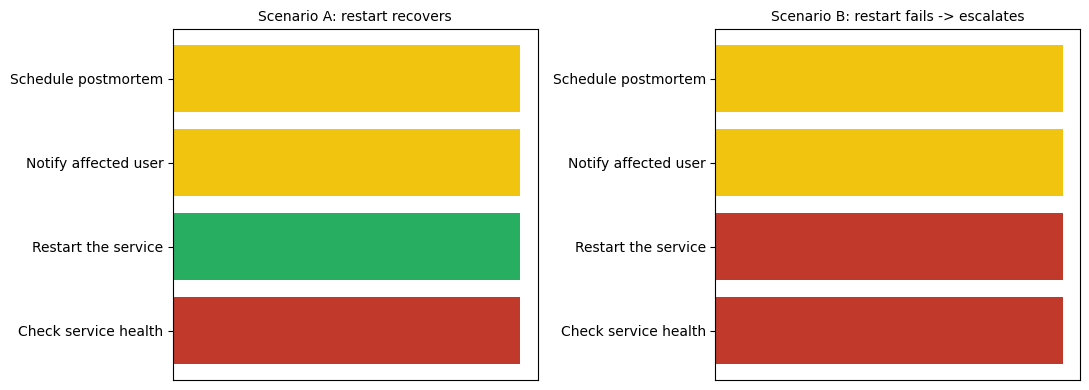

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
status_colors = {"done": "#27AE60", "failed": "#C0392B", "awaiting_human": "#F1C40F"}

for ax, (title, execs) in zip(axes, [("Scenario A: restart recovers", executions_a), ("Scenario B: restart fails -> escalates", executions_b)]):
    labels = [e.step.description[:20] for e in execs]
    colors = [status_colors[e.status] for e in execs]
    ax.barh(labels, [1] * len(execs), color=colors)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])

plt.tight_layout()
plt.savefig("incident_scenarios.png", dpi=150)
plt.show()

## Summary

Same incident type, same detection failure — the only difference is whether the remediation step
(restart) actually fixes it. That's the signal that matters for paging, not the initial alert. The
agent runs every step of the runbook every time, so nothing gets skipped because someone was busy.


## Try Your Own

Uncomment and edit to simulate a different incident (try `disk_space_critical` or `database_high_latency` — see `incident_agent.py` for the full runbook set):

In [5]:
# my_incident = Incident("service_down", "P2", datetime.now(), context={"service_healthy": False, "restart_recovers": True})
# _, my_execs, my_escalated, my_escalated_to, my_summary = execute_runbook(my_incident)
# for e in my_execs:
#     print(e.status, e.step.description, e.output)
# print(my_summary)

---
**[← Back to portfolio](../../README.md)**

For the interactive version with a UI and 3 runbook types (service down, disk space, DB latency):
```bash
pip install -r requirements.txt
streamlit run app.py
```
Set `ANTHROPIC_API_KEY` for a Claude-written incident summary instead of the rule-based one.
